# Fitness Spread

In [23]:
from pathlib import Path
from tqdm.auto import tqdm

import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import cartopy 

from load_tuning_results import (
    load_results_raw,
    load_results,
    load_result_for_key,
    add_derived_features,
    filter_suspicious_routes,
    # get_cost_spread_df,
)

In [24]:
import warnings

warnings.filterwarnings("ignore")

In [25]:
gdf = gpd.read_parquet("../results/results_prelim.geoparquet")
gdf = add_derived_features(gdf)
gdf

,hyper_population_size,hyper_random_seed,hyper_selection_acceptance_rate_warmup,hyper_mutation_width_fraction_warmup,hyper_mutation_displacement_fraction_warmup,hyper_generations,hyper_offspring_size,hyper_crossover_rounds,hyper_selection_quantile,hyper_selection_acceptance_rate,...,forcing_scenario_name,forcing_currents_path,forcing_waves_path,forcing_winds_path,diversity_cost_q75_25_rms,diversity_cost_q50_00_rms,hyper_num_individuals,journey_duration,seed_cost,elite_speed_og_mps_average
filename,,,,,,,,,,,,,,,,,,,,,
result:0000:seed3895092605,128,3895092605,0.3,0.99,0.10,2,4,1,0.10,0.00,...,baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,5.054044e+22,1.181028e+23,256,11 days 10:10:42,5.926383e+12,6.446294
result:0000:seed3895092605,128,3895092605,0.3,0.99,0.10,2,4,1,0.10,0.00,...,baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,5.054044e+22,1.181028e+23,256,11 days 10:10:42,5.926383e+12,6.446294
result:0001:seed1649728346,256,1649728346,0.3,0.99,0.10,4,4,2,0.25,0.00,...,baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,1.036964e+28,2.193217e+28,1024,17 days 03:16:03,3.604302e+14,4.551052
result:0001:seed1649728346,256,1649728346,0.3,0.99,0.10,4,4,2,0.25,0.00,...,baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,1.036964e+28,2.193217e+28,1024,17 days 03:16:03,3.604302e+14,4.551052
result:0002:seed3030206584,128,3030206584,0.3,0.99,0.25,2,4,1,0.10,0.25,...,baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,1.638432e+27,3.180526e+26,256,13 days 17:00:51,7.524805e+13,5.326478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
result:3997:seed3352588423,64,3352588423,0.3,0.99,0.25,1,4,1,0.25,0.25,...,no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,0.000000e+00,1.962231e+15,64,17 days 03:16:03,1.424118e+13,4.115572
result:3998:seed2264517074,128,2264517074,0.3,0.99,0.10,1,4,0,0.10,0.00,...,no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,5.408267e+20,3.913984e+21,128,11 days 10:10:42,6.351398e+12,6.186218
result:3998:seed2264517074,128,2264517074,0.3,0.99,0.10,1,4,0,0.10,0.00,...,no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,5.408267e+20,3.913984e+21,128,11 days 10:10:42,6.351398e+12,6.186218


<Axes: xlabel='diversity_cost_q75_25_rms', ylabel='elite_cost_absolute'>

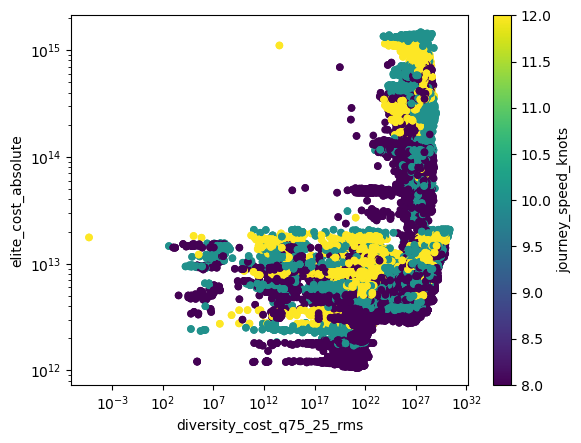

In [26]:
gdf.plot.scatter(x="diversity_cost_q75_25_rms", y="elite_cost_absolute", c="journey_speed_knots", logy=True, logx=True)

<Axes: xlabel='diversity_cost_q50_00_rms', ylabel='elite_cost_relative'>

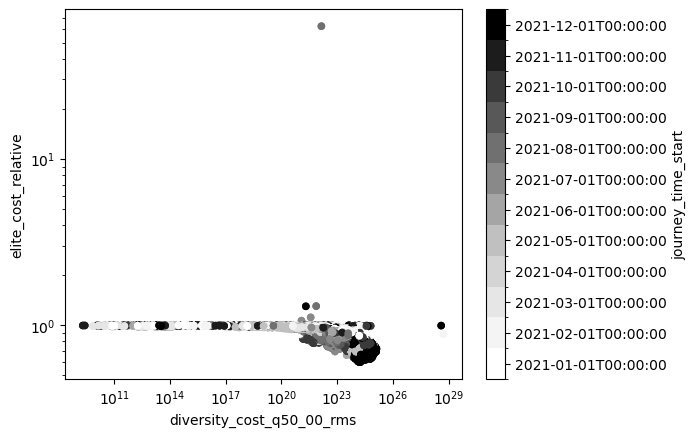

In [61]:
gdf.loc[gdf.hyper_hazard_penalty_multiplier == 0].plot.scatter(x="diversity_cost_q50_00_rms", y="elite_cost_relative", c="journey_time_start", logy=True, logx=True)

(0.0, 1.1)

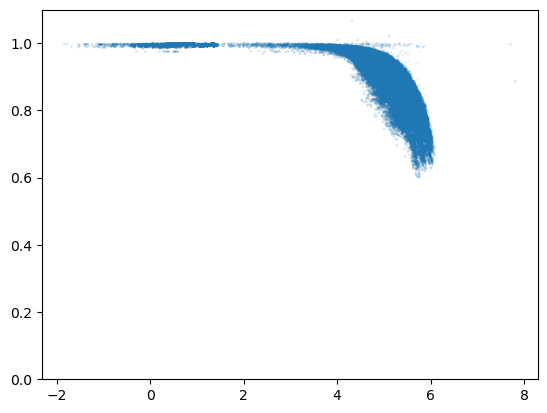

In [57]:
_gdf = gdf.loc[gdf.hyper_hazard_penalty_multiplier == 0]
plt.scatter(
    np.log10(np.sqrt(_gdf.diversity_cost_q50_00_rms / _gdf.elite_cost_absolute)),
    _gdf.elite_cost_relative,
    s=3,
    edgecolor="none",
    alpha=0.1,
)
plt.ylim(0, 1.1)

(0.0, 1.1)

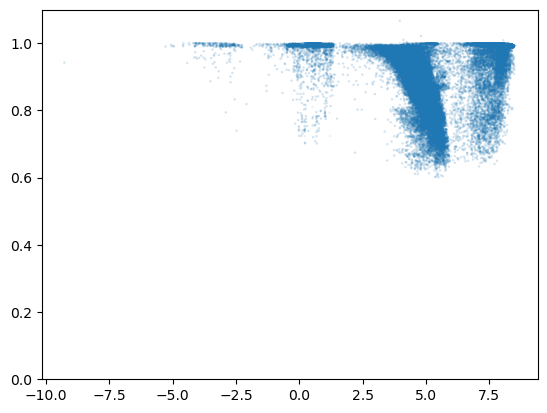

In [58]:
_gdf = gdf.loc[gdf.hyper_hazard_penalty_multiplier == 0]
plt.scatter(
    np.log10(np.sqrt(_gdf.diversity_cost_q75_25_rms / _gdf.elite_cost_absolute)),
    _gdf.elite_cost_relative,
    s=3,
    edgecolor="none",
    alpha=0.1,
)
plt.ylim(0, 1.1)